## Notebook 5: Illustration of Adjoint Method

This notebook illustrates the training and prediction of a very simple Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated from solving

$\frac{du}{dt}=-u^2$

with initial condition $u(0)=1.0$. Training data is generated for $t\in[0,2]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,5]$.  

The NODEs model look like

$\frac{du}{dt}=NN(u;\vec{p})$


The Neural Network has one input, $u$ and one output $du(t)/dt$.  In this Notebook, the parameters of the Neural Network, $NN(u;\vec{p})$, will be obtained manually using the Discrete Adjoint method, without using any of the  SciML package in Julia. 

In [1]:
using OrdinaryDiffEq
using CairoMakie
using OrdinaryDiffEqTsit5
using LinearAlgebra

Training parameters

In [2]:
max_iter_NODEs=50_000
α=0.1 #learning rate

0.1

Parameters of the training and validation data set

In [3]:
u0 = Float32[1.0]
datasize = 150
tspan = (0.0f0, 2.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

tspan2 = (0.0f0, 5.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 200)

noise=0.002

0.002

Define governing equation

$\frac{du}{dt}=-u^2$


In [4]:
function trueODEfunc(du, u, p, t)
    du[1]=-u[1]*u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data and add a bit of noise.  The training data is for $t\in[0,20]$

In [5]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

1×150 Matrix{Float64}:
 1.00151  0.989772  0.974752  0.958623  …  0.333289  0.336771  0.334293

Generating the validation  data, for $t\in[0,5]$ 

In [6]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

1×200 Matrix{Float32}:
 1.0  0.97549  0.952153  0.929907  0.908676  …  0.168083  0.167376  0.166675

Plot the training and validation data

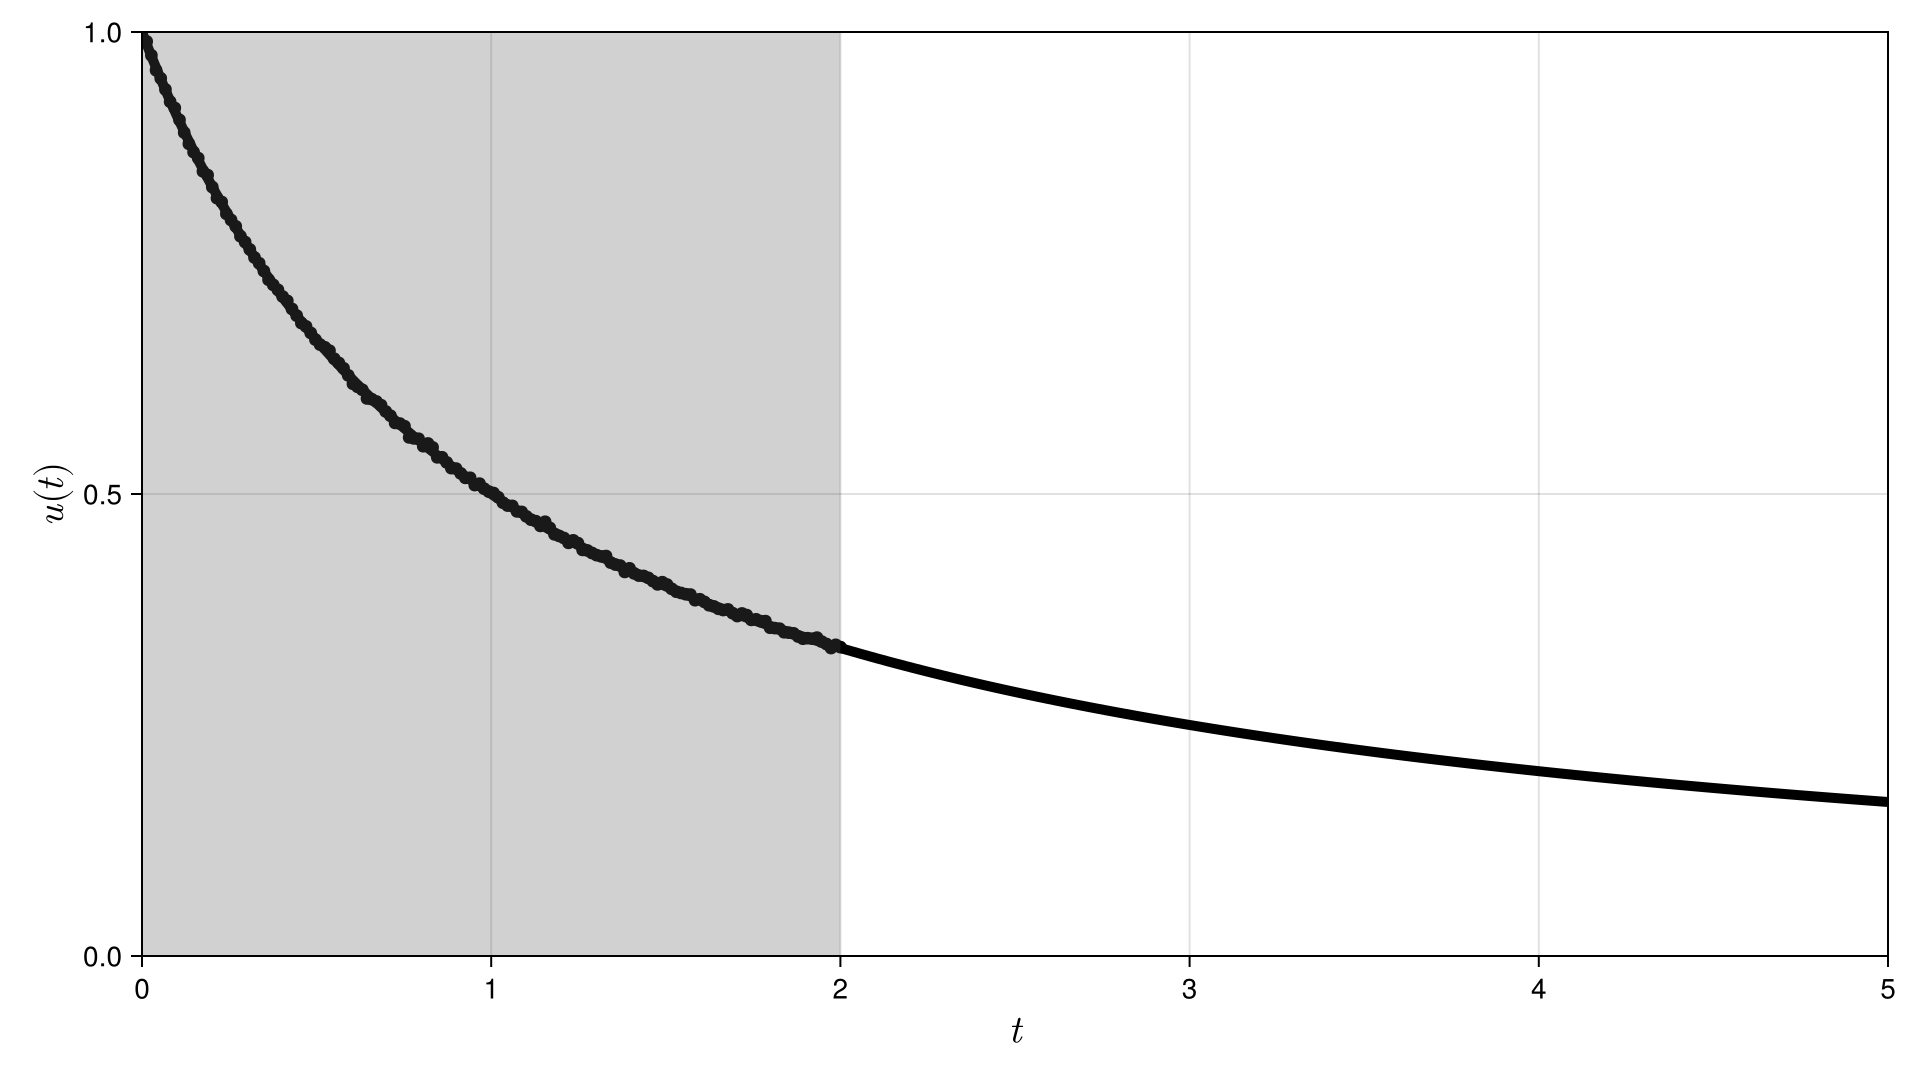

In [7]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",
    ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[:]; linewidth = 5,color=:black,label="True solution")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
fig

Now we will use the discrete adjoine method to train the  NODEs using the data from $t\in[0,2]$.  Our model is

$\frac{du}{dt}=-(Wu+b)^2$

This is a very simple Neural Network with a simple quadratic as the activation function.  Our task is to find the components of the vector, $\vec{p}$.

$$
\vec{p}=\begin{Bmatrix}W\\
b\end{Bmatrix}
$$

In this notebook, we will illustrate the use of the discrete adjoint method.  Consider the problem as a constrained optimization problem where we would like to optimize

$
\mathcal{L}=\frac{1}{N}\frac{1}{2}\sum_{i=1}^{N}\left((u^{(i)}_{pred}-u^{(i)}_{data}\right)^2
$

subject to the constraint

$
\vec{g}(\vec{u},\vec{p})=\vec{0}
$

For our model, if we assume that we have five intervals between the first and last time point, interval size is $\Delta t$, and using the Euler time stepping scheme

$
\vec{g}=\begin{Bmatrix}
u_{pred}^{(1)}-1\\
u^{(2)}_{pred}-u^{(1)}_{pred}-(Wu^{(1)}_{pred}+b)^2\Delta t \\
u^{(3)}_{pred}-u^{(2)}_{pred}-(Wu^{(2)}_{pred}+b)^2\Delta t \\
u^{(4)}_{pred}-u^{(3)}_{pred}-(Wu^{(3)}_{pred}+b)^2\Delta t \\
u^{(5)}_{pred}-u^{(4)}_{pred}-(Wu^{(4)}_{pred}+b)^2\Delta t \\
u^{(6)}_{pred}-u^{(5)}_{pred}-(Wu^{(5)}_{pred}+b)^2\Delta t \\
\end{Bmatrix}=\vec{0}
$

For brevity, we will now assume that $u=u_{pred}$ (unless otherwise stated)

We want to use gradient descent to optimize $\vec{p}$ so that we minimize $\mathcal{L}$.  To use gradient descent, we need to calculate

$
\frac{d \mathcal{L}}{d \vec{p}}=\frac{\partial \mathcal{L}}{\partial \vec{u}} \left(\frac{\partial \vec{u}}{\partial \vec{p}}\right)
$

$\frac{\partial \mathcal{L}}{\partial \vec{u}}$ is easy to find.  The difficulty is we need to find the senstivity of the solution to $\vec{p}$, $\frac{\partial \vec{u}}{\partial \vec{p}}$. Using the implicit function theorem


$\frac{d \vec{g}}{d \vec{p}}=\frac{\partial \vec{g}}{\partial \vec{u}} \frac{\partial \vec{u}}{\partial \vec{p}} +  \frac{\partial \vec{g}}{\partial \vec{p}} =0$

Thefore

$
 \frac{\partial \vec{u}}{\partial \vec{p}} =-  \left(\frac{\partial \vec{g}}{\partial \vec{u}} \right)^{-1}\frac{\partial \vec{g}}{\partial \vec{p}}
$

Substitute into the expression for $\frac{d \mathcal{L}}{d \vec{p}}$ gives


$
\frac{d \mathcal{L}}{d \vec{p}}=-\left[\frac{\partial \mathcal{L}}{\partial \vec{u}}  \left(\frac{\partial \vec{g}}{\partial \vec{u}} \right)^{-1}\right]\frac{\partial \vec{g}}{\partial \vec{p}}
$

Let

$
\vec{\lambda}^{T}=\left[\frac{\partial \mathcal{L}}{\partial \vec{u}}  \left(\frac{\partial \vec{g}}{\partial \vec{u}} \right)^{-1}\right]
$

$
\left(\frac{\partial \vec{g}}{\partial \vec{u}}\right)^{T}
\vec{\lambda} =\left(\frac{\partial \mathcal{L}}{\partial \vec{u}}\right)^{T}
$

and

$
\frac{d \mathcal{L}}{d \vec{p}}=\vec{\lambda}^{T}\frac{\partial \vec{g}}{\partial \vec{p}}
$



If we assume that we have five intervals between the first and last time point, interval size is $\Delta t$, and using the Euler time stepping scheme, we would need to solve


$
\begin{bmatrix}
1 & -1-2(Wu^{(1)}+b)W\Delta t & 0 & 0 & 0 &0 \\
0 & 1 & -1-2(Wu^{(2)}+b)W\Delta t & 0 & 0 & 0\\
0 & 0 & 1 & -1-2(Wu^{(3)}+b)W\Delta t & 0 & 0 \\
0 & 0 & 0 & 1 & -1-2(Wu^{(4)}+b)W\Delta t & 0  \\
0 & 0 & 0& 0 & 1 & -1-2(Wu^{(5)}+b)W\Delta t  \\
0 & 0 & 0& 0&  0 & 1  \\
 \end{bmatrix}\begin{Bmatrix}\lambda_1 \\
 \lambda_2 \\
 \lambda_3 \\
 \lambda_4 \\
\lambda_5 \\
\lambda_6
\end{Bmatrix}=\frac{1}{6}\begin{Bmatrix}\left((u^{(1)}-u^{(1)}_{data}\right) \\ \left((u^{(2)}-u^{(2)}_{data}\right) \\
\left((u^{(3)}-u^{(3)}_{data}\right)\\
\left((u^{(4)}-u^{(4)}_{data}\right)\\
\left((u^{(5)}-u^{(5)}_{data}\right)\\
\left((u^{(6)}-u^{(6)}_{data}\right)
\end{Bmatrix}
 $

 for $\lambda_i$ and then use the  $\lambda_i$ to compute


$ \begin{bmatrix}\frac{d L}{d W} \frac{d L}{d b}\end{bmatrix}=\begin{bmatrix}\lambda_1 &
 \lambda_2 &
 \lambda_3 &
 \lambda_4 &
\lambda_5 &
\lambda_6
\end{bmatrix}\begin{bmatrix}
0 & 0 \\
-(Wu^{(1)}+b)u^{(1)}\Delta t & -(Wu^{(1)}+b)\Delta t \\
-(Wu^{(2)}+b)u^{(2)}\Delta t & -(Wu^{(2)}+b)\Delta t \\
-(Wu^{(3)}+b)u^{(3)}\Delta t &   
-(Wu^{(3)}+b)\Delta t \\
-(Wu^{(4)}+b)u^{(4)}\Delta t & -(Wu^{(4)}+b)\Delta t \\
-(Wu^{(5)}+b)u^{(5)}\Delta t & -(Wu^{(5)}+b)\Delta t\\
\end{bmatrix}$

In [8]:
u=zeros(datasize)
dt=tsteps[2]-tsteps[1]

d=ones(datasize)
dl=zeros(datasize-1)

u[1]=u0[1]
W=0.5 #Initial guess of weight
b=0.5 # initial guess of bias

loss=[]

for i=1:max_iter_NODEs

    # Forward model Euler timestepping
    for n=1:datasize-1
        u[n+1]=u[n]-dt*(W*u[n]+b).^2
    end

    push!(loss,0.5*sum((u.-data').^2)/datasize)

    #calculate gradients using discrete adjoint method
    du=-ones(datasize-1)-2*(W*u[1:end-1].+b)*W*dt
    dgduT = Tridiagonal(dl, d, du)
    dLdu=(u.-data')/datasize
    lambda=dgduT\dLdu #adjoints

    dgdW=vcat(0,-2*(W*u[1:end-1].+b).*u[1:end-1]*dt)
    dLdW=lambda'*dgdW

    dgdb=vcat(0,-2*(W*u[1:end-1].+b).*dt)    
    dLdb=lambda'*dgdb

    W-=α*dLdW[1]
    b-=α*dLdb[1]
end


In [9]:
(W,b)

(0.9912134322066298, 0.00250439117836023)

The optimized values of $W$ and $b$ are close to 1 and 0 respectively, which is what we would expect.

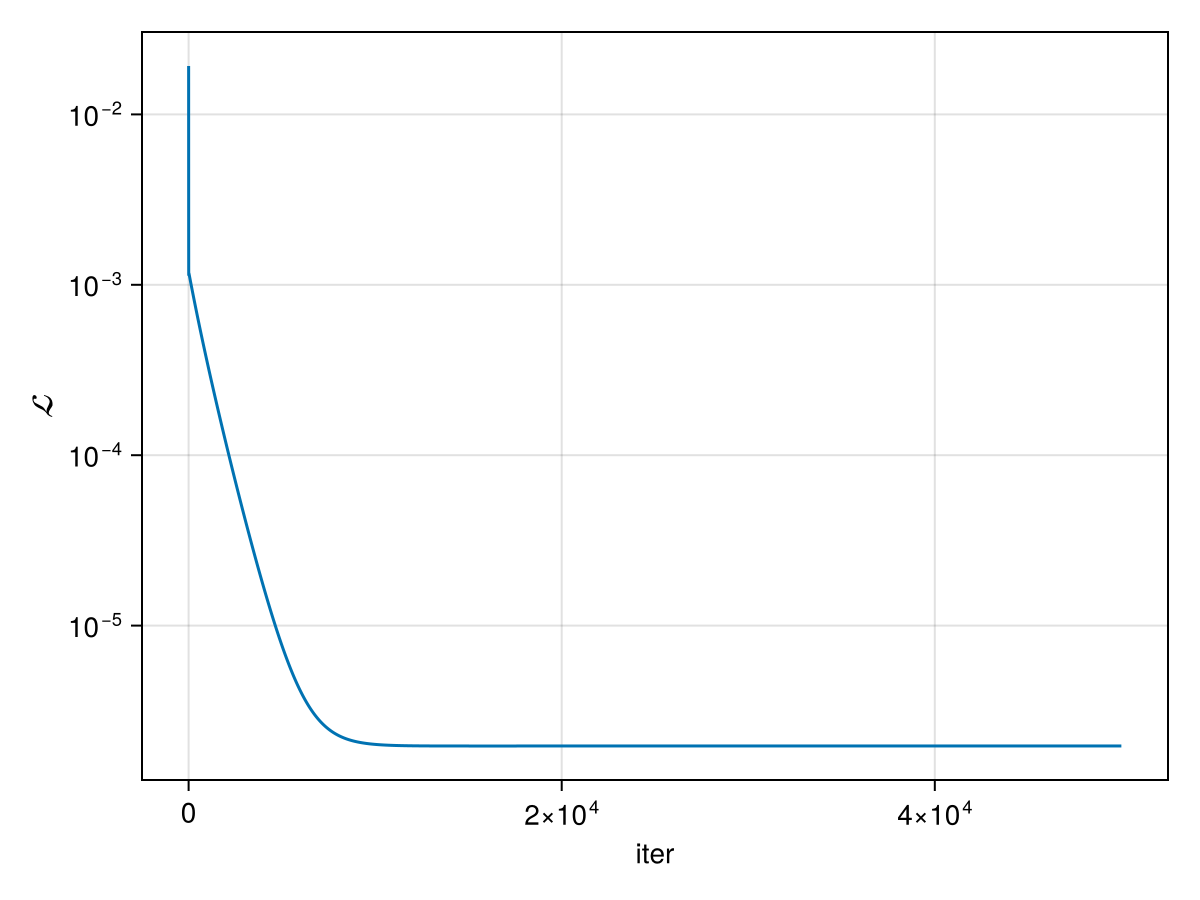

In [10]:
#Plot history of the loss function

fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss)
fig

Now we predict using the optimized $W$ and $b$. 

In [11]:
u=zeros(length(tsteps2))
dt=tsteps2[2]-tsteps2[1]
u[1]=u0[1]
for n=1:length(tsteps2)-1
    u[n+1]=u[n]-dt*(W*u[n]+b)^2
end

Plot the NODEs solution and compare

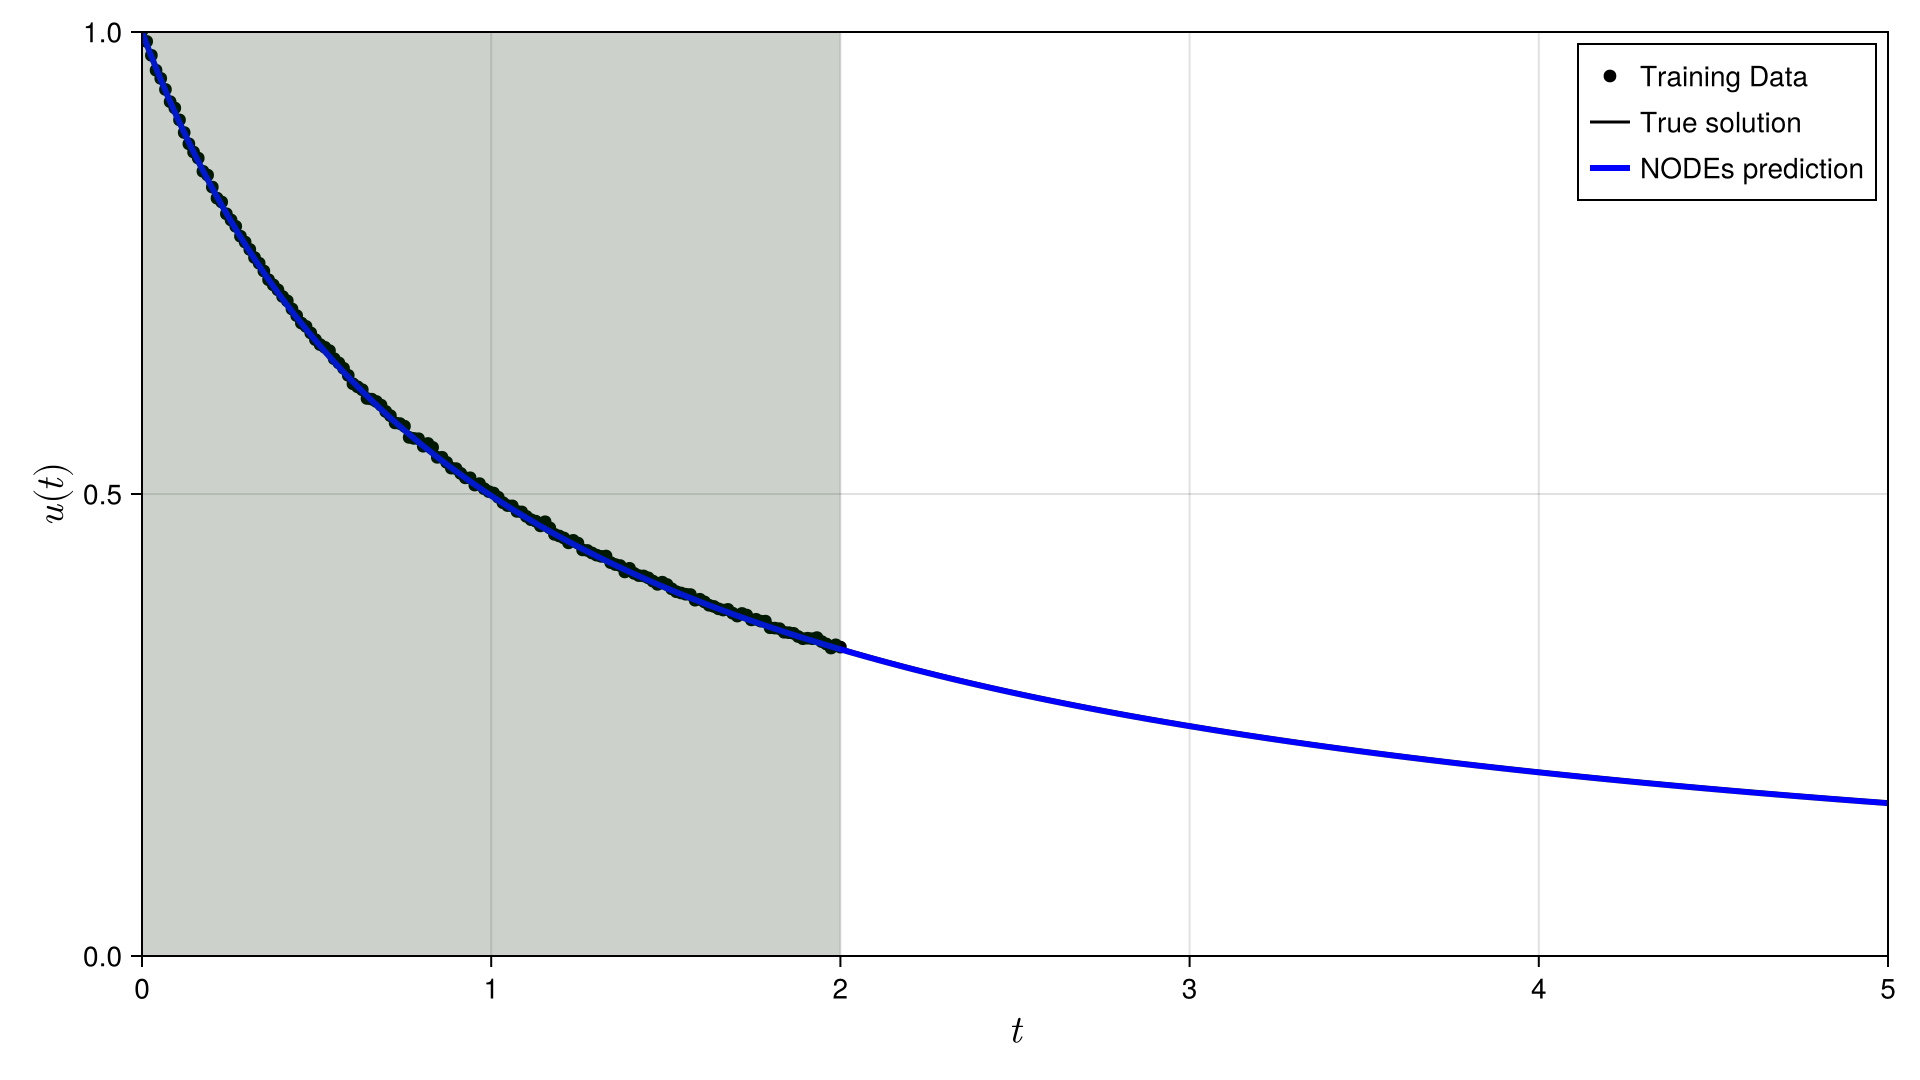

In [12]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",
    ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; color=:black,label="True solution")
CairoMakie.lines!(ax,tsteps2,u; linewidth = 3,color=:blue,linestyle=:solid,label="NODEs prediction")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:green, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
fig